In [1]:
from pathlib import Path
from maize.core.workflow import Workflow
from maize.core.node import Node
from maize.steps.io import LoadData, LogResult, Void, FileParameter, Return
from maize.steps.mai.molecule import LoadSmiles, LoadMolecule, Gypsum
from maize.core.interface import Input, Output
from maize.utilities.chem import IsomerCollection
from rdkit import Chem
from rdkit.Chem import Descriptors
from rdkit.Chem.Draw import IPythonConsole
import pandas as pd
from pandas import DataFrame

In [2]:
for desc in Descriptors._descList:
    print(desc)

('MaxAbsEStateIndex', <function MaxAbsEStateIndex at 0x7f9f8bfcec20>)
('MaxEStateIndex', <function MaxEStateIndex at 0x7f9f8bfceb00>)
('MinAbsEStateIndex', <function MinAbsEStateIndex at 0x7f9f8bfcecb0>)
('MinEStateIndex', <function MinEStateIndex at 0x7f9f8bfceb90>)
('qed', <function qed at 0x7f9f8c005900>)
('SPS', <function SPS at 0x7f9f8c005c60>)
('MolWt', <function <lambda> at 0x7f9f8c006290>)
('HeavyAtomMolWt', <function HeavyAtomMolWt at 0x7f9f8c006320>)
('ExactMolWt', <function <lambda> at 0x7f9f8c0063b0>)
('NumValenceElectrons', <function NumValenceElectrons at 0x7f9f8c006440>)
('NumRadicalElectrons', <function NumRadicalElectrons at 0x7f9f8c0064d0>)
('MaxPartialCharge', <function MaxPartialCharge at 0x7f9f8c0065f0>)
('MinPartialCharge', <function MinPartialCharge at 0x7f9f8c006680>)
('MaxAbsPartialCharge', <function MaxAbsPartialCharge at 0x7f9f8c006710>)
('MinAbsPartialCharge', <function MinAbsPartialCharge at 0x7f9f8c0067a0>)
('FpDensityMorgan1', <function FpDensityMorgan1 a

In [3]:
class CalcDesc(Node):
    out: Output[pd.DataFrame] = Output()
    inp: Input[list[str]] = Input()

    def run(self):
        res = pd.DataFrame({'smiles': self.inp.receive()})
        res['ROMol'] = res['smiles'].apply(Chem.MolFromSmiles)
        res['MolWt'] = res['ROMol'].apply(Descriptors.MolWt)
        res['MolLogP'] = res['ROMol'].apply(Descriptors.MolLogP)
        return self.out.send(res)

In [4]:
mols = ['CCC', 'CCOC', 'CCCC']

In [5]:
flow = Workflow()
load = flow.add(LoadData[list[str]])
calc = flow.add(CalcDesc)
res = flow.add(Return[pd.DataFrame])
flow.connect(load.out, calc.inp)
flow.connect(calc.out, res.inp)
load.data.set(mols)
flow.check()

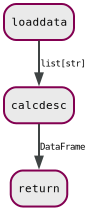

In [6]:
flow.visualize()

In [7]:
flow.execute()

2026-02-28 15:34:04,684 |     INFO |           36yis8 | 
              ___           ___                       ___           ___
             /\__\         /\  \          ___        /\  \         /\  \
            /::|  |       /::\  \        /\  \       \:\  \       /::\  \
           /:|:|  |      /:/\:\  \       \:\  \       \:\  \     /:/\:\  \
          /:/|:|__|__   /::\~\:\  \      /::\__\       \:\  \   /::\~\:\  \
         /:/ |::::\__\ /:/\:\ \:\__\  __/:/\/__/ _______\:\__\ /:/\:\ \:\__\
         \/__/~~/:/  / \/__\:\/:/  / /\/:/  /    \::::::::/__/ \:\~\:\ \/__/
               /:/  /       \::/  /  \::/__/      \:\~~\~~      \:\ \:\__\
              /:/  /        /:/  /    \:\__\       \:\  \        \:\ \/__/
             /:/  /        /:/  /      \/__/        \:\__\        \:\__\
             \/__/         \/__/                     \/__/         \/__/


2026-02-28 15:34:04,684 |     INFO |           36yis8 | Starting Maize version 0.9.4 (c) AstraZeneca 2026
2026-02-28 15:3

In [8]:
res.get()

,smiles,ROMol,MolWt,MolLogP
0,CCC,<rdkit.Chem.rdchem.Mol object at 0x7fa142e4a7f0>,44.097,1.4163
1,CCOC,<rdkit.Chem.rdchem.Mol object at 0x7fa142e4a890>,60.096,0.6527
2,CCCC,<rdkit.Chem.rdchem.Mol object at 0x7fa142e4a930>,58.124,1.8064


In [9]:
from maize.utilities.chem.chem import IsomerCollection
iso1 = IsomerCollection.from_smiles('CCC(O)CN')

In [10]:
iso1

IsomerCollection('CCC(O)CN', n_isomers=2)

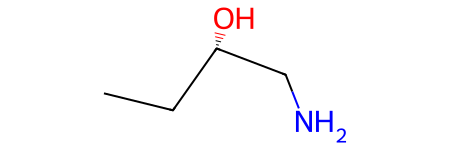

In [11]:
iso1.molecules[0]._molecule

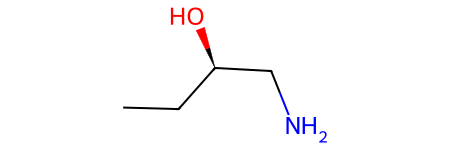

In [12]:
iso1.molecules[1]._molecule

In [13]:
class Smi2Mols(Node):
    inp: Input[list[str]] = Input()
    out: Output[list[IsomerCollection]] = Output()

    def run(self) -> None:
        smiles_list = self.inp.receive()
        mols = [IsomerCollection.from_smiles(smi) for smi in smiles_list]
        self.out.send(mols)

In [14]:
flow = Workflow()
load = flow.add(LoadData[list[str]])
emb = flow.add(Smi2Mols)
ret = flow.add(Return[list[IsomerCollection]])
flow.connect(load.out, emb.inp)
flow.connect(emb.out, ret.inp)
load.data.set(['CC', 'CCC(O)CN'])
flow.check()

In [15]:
flow.execute()

2026-02-28 15:38:11,819 |     INFO |           5m01uy | 
              ___           ___                       ___           ___
             /\__\         /\  \          ___        /\  \         /\  \
            /::|  |       /::\  \        /\  \       \:\  \       /::\  \
           /:|:|  |      /:/\:\  \       \:\  \       \:\  \     /:/\:\  \
          /:/|:|__|__   /::\~\:\  \      /::\__\       \:\  \   /::\~\:\  \
         /:/ |::::\__\ /:/\:\ \:\__\  __/:/\/__/ _______\:\__\ /:/\:\ \:\__\
         \/__/~~/:/  / \/__\:\/:/  / /\/:/  /    \::::::::/__/ \:\~\:\ \/__/
               /:/  /       \::/  /  \::/__/      \:\~~\~~      \:\ \:\__\
              /:/  /        /:/  /    \:\__\       \:\  \        \:\ \/__/
             /:/  /        /:/  /      \/__/        \:\__\        \:\__\
             \/__/         \/__/                     \/__/         \/__/


2026-02-28 15:38:11,819 |     INFO |           5m01uy | Starting Maize version 0.9.4 (c) AstraZeneca 2026
2026-02-28 15:3

In [16]:
results = ret.get()

In [17]:
results

[IsomerCollection('CC', n_isomers=1),
 IsomerCollection('CCC(O)CN', n_isomers=2)]